<a href="https://colab.research.google.com/github/127003278/potato-leaf-disese-classification/blob/main/Efficientnet_B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Model1/Training"

In [ ]:
import os
os.listdir(dataset_path)
print(len(os.listdir(dataset_path)))

3


# Image preprocessing

In [ ]:
import tensorflow as tf
import numpy as np
#Image Preprocessing

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

Found 6000 files belonging to 3 classes.
Using 4800 files for training.


In [ ]:
print(train_ds.class_names)


['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

Found 6000 files belonging to 3 classes.
Using 1200 files for validation.


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

# Efficientnet B0 Training

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
import os

for folder in os.listdir(dataset_path):
    print(folder, len(os.listdir(dataset_path + "/" + folder)))

Healthy 2000
Early_Blight 2000
Late_Blight 2000


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(3, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.3,
    patience = 3,
    min_lr = 1e-6
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 840s 5s/step - accuracy: 0.7806 - loss: 0.5634 - val_accuracy: 0.9317 - val_loss: 0.2614 - learning_rate: 1.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9262 - loss: 0.2411 - val_accuracy: 0.9475 - val_loss: 0.1757 - learning_rate: 1.0000e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9419 - loss: 0.1772 - val_accuracy: 0.9592 - val_loss: 0.1400 - learning_rate: 1.0000e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9573 - loss: 0.1443 - val_accuracy: 0.9692 - val_loss: 0.1185 - learning_rate: 1.0000e-04
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9619 - loss: 0.1286 - val_accuracy: 0.9708 - val_loss: 0.1064 - learning_rate: 1.0000e-04
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9646 - loss: 0.1125 - val_accuracy: 0.9725 - val_loss: 0.0986 - learning_rate: 1.0000e-04
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - acc

# Comparision Matrix for Validation dataset

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step
[[375   3   8]
 [  1 406   0]
 [  4   5 398]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       386
           1       0.98      1.00      0.99       407
           2       0.98      0.98      0.98       407

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



# Fine-tuning

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 63s 186ms/step - accuracy: 0.9421 - loss: 0.1763 - val_accuracy: 0.9767 - val_loss: 0.0819
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9635 - loss: 0.1148 - val_accuracy: 0.9725 - val_loss: 0.0897
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9719 - loss: 0.0917 - val_accuracy: 0.9767 - val_loss: 0.0857
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9752 - loss: 0.0781 - val_accuracy: 0.9775 - val_loss: 0.0787
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9794 - loss: 0.0661 - val_accuracy: 0.9792 - val_loss: 0.0738
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9831 - loss: 0.0591 - val_accuracy: 0.9817 - val_loss: 0.0696
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9858 - loss: 0.0515 - val_accuracy: 0.9817 - val_loss: 0.0666
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9865 - loss: 0.0486 - val_ac

# Saving Model

In [ ]:
model.save("/content/drive/MyDrive/Model1/Model/efficientnetB0.keras")

# Testing dataset Preprocessing

In [ ]:
test_path = '/content/drive/MyDrive/Model1/Testing'

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 552 files belonging to 3 classes.


In [ ]:
class_names = test_ds.class_names
print(class_names)

['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
test_ds = test_ds.map(lambda x,y: (preprocess_input(x),y))
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

#Evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.9873 - loss: 0.0636
Test Accuracy: 0.9873188138008118
Test Loss: 0.06363993138074875


# Performance Metrics

In [ ]:
import numpy as np

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x,y in test_ds], axis=0)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes) * 100
precision = precision_score(y_true, y_pred_classes, average="weighted") * 100
recall = recall_score(y_true, y_pred_classes, average="weighted") * 100
f1 = f1_score(y_true, y_pred_classes, average="weighted") * 100

print("Accuracy: {:.2f}%".format(accuracy))
print("Precision: {:.2f}%".format(precision))
print("Recall: {:.2f}%".format(recall))
print("F1 Score: {:.2f}%".format(f1))

Accuracy: 98.73%
Precision: 98.76%
Recall: 98.73%
F1 Score: 98.74%


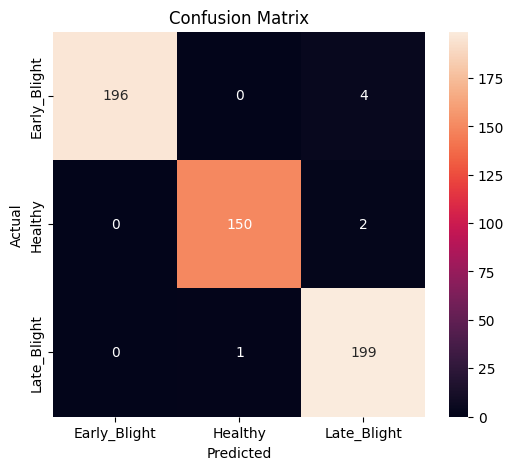

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()